In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(14.4,7.4)



In [2]:
# load cross-section from uncertainty

energy_t = np.array([
    1.000000E-04,
    5.000000E-04,
    9.999999E-04,
    5.000000E-03,
    1.000000E-02,
    5.000000E-02,
    9.999999E-02,
    1.500000E-01,
    2.000000E-01,
    2.500000E-01,
    3.000000E-01,
    4.000000E-01,
    5.000000E-01,
    6.000000E-01,
    7.000000E-01,
    8.000000E-01,
    9.000000E-01,
    1.000000E+00,
    1.500000E+00,
    2.000000E+00,
    2.500000E+00,
    3.000000E+00,
    3.500000E+00,
    4.000000E+00,
    5.000000E+00,
    6.000000E+00,
    7.000000E+00,
    8.000000E+00,
    9.000000E+00,
    1.000000E+01
])



func_rand =  np.loadtxt('reaction_rate.txt')

print(func_rand.shape)
print(energy_t.shape)

print(func_rand)

(100, 30)
(30,)
[[30030880.   20432780.   16662710.   ...   211981.5    113925.3
     61839.72]
 [43499410.   30684180.   25055300.   ...   699211.9    416006.
    248118.1 ]
 [30254240.   20584560.   16787980.   ...   254088.     138466.2
     76098.65]
 ...
 [31296000.   21344750.   17391410.   ...   280719.4    153879.8
     84946.09]
 [27418420.   18530800.   15142960.   ...   261763.5    145187.2
     81068.49]
 [30605130.   20840710.   17004790.   ...   255027.2    137980.7
     75412.56]]


In [3]:
# talys all combinations
rr_comb_up =  np.loadtxt('rr_up.txt')
print(rr_comb_up.shape)

rr_comb_down =  np.loadtxt('rr_down.txt')
print(rr_comb_down.shape)


rr_comb =np.vstack((rr_comb_up,rr_comb_down))
print(rr_comb.shape)


(60, 30)
(60, 30)
(120, 30)


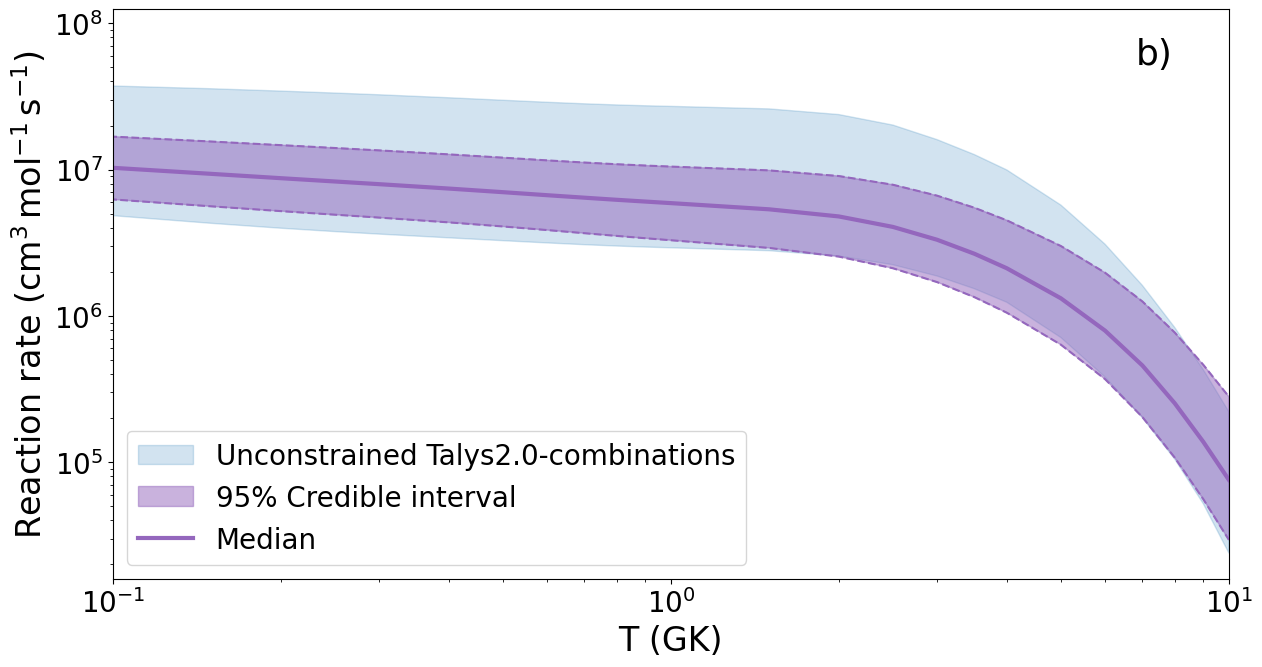

In [5]:
#plot both together 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig = plt.figure()


upper_comb = (np.percentile(rr_comb, 100, axis = 0))
lower_comb = (np.percentile(rr_comb, 0, axis = 0))
plt.fill_between(energy_t, lower_comb, upper_comb, color=colors[0], alpha=0.2,label='Unconstrained Talys2.0-combinations')





median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))

prediction_color_number=4

lower = (np.percentile(func_rand, 2.5, axis = 0))


plt.fill_between(energy_t, lower, upper, color=colors[prediction_color_number], alpha=0.5,label='95% Credible interval')


plt.plot(energy_t, median, color=colors[prediction_color_number],linewidth=3,label='Median')
plt.plot(energy_t, lower, color=colors[prediction_color_number],linestyle='dashed')
plt.plot(energy_t, upper, color=colors[prediction_color_number],linestyle='dashed')




'''
plt.errorbar(df1['energy'], df1['xs'],yerr= df1['dxs'],fmt="o", color="r",ecolor='r',label='2011 Tagliente et al.',linestyle='None')
plt.errorbar(df2['energy'], df2['xs'],yerr= df2['dxs'],fmt="s", color="b",ecolor='b',label='2018 S.Badwar et al.',linestyle='None')
plt.errorbar(df3['energy'], df3['xs'],yerr= df3['dxs'],xerr=df3['denergy'],fmt="^", color="brown",ecolor='brown',label='2011 Katabuchi et al.',linestyle='None')
plt.errorbar(df4['energy'], df4['xs'],yerr= df4['dxs'],xerr=df4['denergy'],fmt="+", color="olive",ecolor='olive',label='1982 Wyrich et al.',linestyle='None')
plt.errorbar(df5['energy'], df5['xs'],yerr= df5['dxs'],xerr=df5['denergy'],fmt="*", color="green",ecolor='green',label='1959 Lyon et al.',linestyle='None')
plt.errorbar(df6['energy'], df6['xs'],yerr= df6['dxs'],fmt="x", color="black",ecolor='black',label='1990 Toukan et al.',linestyle='None')
'''

#plt.plot(dfd_['energy'], dfd_['xs'],color='green',marker='*',label= 'cross-section-talys ',linewidth=6)
#plt.plot(dfd_2['energy'], dfd_2['xs'],color='green',marker='*',label= 'cross-section-ld5 ptable =0.5')

#plt.plot(dfd_2['energy'], dfd_2['xs'],color='purple',marker='*',label= '96Zr(n,g) oslo -elevated gsf')


'''
for i in range(96):
    plt.plot(energy_t, xs_comb[i], color='blue')
'''


plt.yscale("log")
plt.xscale("log")

plt.xlabel("T (GK)", fontsize=24)

plt.ylabel(r"Reaction rate ($\mathrm{cm^3\,mol^{-1}\,s^{-1}}$)", fontsize=24)
#plt.title("Cross-Section",fontsize = 15)    

plt.xlim(0.1,10)
#plt.ylim(3,100)

plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

#plt.ylim(10**(-9),10**(-4))

#plt.text(0.95, 0.05, 'a)', transform=plt.gca().transAxes,
#         fontsize=24, va='bottom', ha='right')
plt.legend(loc ='lower left',fontsize=20)


plt.text(
    0.95, 0.95, 'b)',
    transform=plt.gca().transAxes,
    fontsize=26,
    va='top',
    ha='right'
)

#plt.savefig(r"cross-section.jpg", format='jpg', dpi=300, bbox_inches='tight')

plt.show()
